## Q1. Scikit-Learn -- Data Preprocessing (Scaling & Encoding)

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder, OneHotEncoder

np.random.seed(42)
df = pd.DataFrame({
 'Age': [25, 30, 35, 40, 28, 32, 45, 50],
 'Salary': [50000, 60000, 75000, 90000, 55000, 65000, 100000, 120000],
 'Department': ['IT', 'HR', 'IT', 'Sales', 'HR', 'Sales', 'IT', 'Sales'],
 'Gender': ['Male', 'Female', 'Female', 'Male', 'Male', 'Female', 'Male', 'Female'],
 'Performance': ['Good', 'Average', 'Excellent', 'Good', 'Average', 'Excellent', 'Good', 'Average']
})

**Perform the following tasks:**

• Apply StandardScaler to the Age and Salary columns. Print the mean and standard deviation of the scaled data to verify it has zero mean and unit variance.

• Apply MinMaxScaler to the Age and Salary columns. Verify that all scaled values lie between 0 and 1.

• Use LabelEncoder to convert the Gender column into numeric labels (0 and 1). Display the mapping between original labels and encoded values.

• Use OneHotEncoder to convert the Department column into dummy variables. Merge the encoded columns back into the original dataframe and drop the original Department column.

• Create a new column Performance_Score by manually mapping Excellent=3, Good=2, Average=1 using the map() function.

• Combine all preprocessing steps above into a single clean dataframe where every column is numeric and ready for machine learning.

In [ ]:
# StandardScaler
scaler = StandardScaler()
df_scaled = df.copy()
df_scaled[['Age', 'Salary']] = scaler.fit_transform(df[['Age', 'Salary']])
print("StandardScaler Mean:\n", df_scaled[['Age', 'Salary']].mean())
print("StandardScaler Std:\n", df_scaled[['Age', 'Salary']].std(ddof=0))

# MinMaxScaler
minmax = MinMaxScaler()
df_minmax = df.copy()
df_minmax[['Age', 'Salary']] = minmax.fit_transform(df[['Age', 'Salary']])
print("\nMinMaxScaler Min:\n", df_minmax[['Age', 'Salary']].min())
print("MinMaxScaler Max:\n", df_minmax[['Age', 'Salary']].max())

# LabelEncoder
le = LabelEncoder()
df['Gender_Encoded'] = le.fit_transform(df['Gender'])
mapping = dict(zip(le.classes_, le.transform(le.classes_)))
print("\nLabelEncoder Mapping:", mapping)

# OneHotEncoder
ohe = OneHotEncoder(sparse_output=False)
dept_encoded = ohe.fit_transform(df[['Department']])
dept_encoded_df = pd.DataFrame(dept_encoded, columns=ohe.get_feature_names_out(['Department']))
df = pd.concat([df, dept_encoded_df], axis=1).drop('Department', axis=1)

# Performance_Score
perf_mapping = {'Excellent': 3, 'Good': 2, 'Average': 1}
df['Performance_Score'] = df['Performance'].map(perf_mapping)

# Combine into clean dataframe (dropping original non-numeric columns for final version)
df_clean = df.drop(['Gender', 'Performance'], axis=1)
# Apply StandardScaler for the clean dataframe's Age and Salary as well
df_clean[['Age', 'Salary']] = scaler.fit_transform(df_clean[['Age', 'Salary']])
df_clean

StandardScaler Mean:
 Age       0.000000e+00
Salary    5.551115e-17
dtype: float64
StandardScaler Std:
 Age       1.0
Salary    1.0
dtype: float64

MinMaxScaler Min:
 Age       0.0
Salary    0.0
dtype: float64
MinMaxScaler Max:
 Age       1.0
Salary    1.0
dtype: float64

LabelEncoder Mapping: {'Female': np.int64(0), 'Male': np.int64(1)}


,Age,Salary,Gender_Encoded,Department_HR,Department_IT,Department_Sales,Performance_Score
0,-1.305531,-1.173358,1,0.0,1.0,0.0,2
1,-0.691164,-0.736760,0,1.0,0.0,0.0,1
2,-0.076796,-0.081862,0,0.0,1.0,0.0,3
3,0.537572,0.573035,1,0.0,0.0,1.0,2
4,-0.936911,-0.955059,1,1.0,0.0,0.0,1
5,-0.445416,-0.518460,0,0.0,0.0,1.0,3
6,1.151939,1.009633,1,0.0,1.0,0.0,2
7,1.766307,1.882830,0,0.0,0.0,1.0,1


**Explain in 2-3 sentences: When should you use StandardScaler versus MinMaxScaler? What happens if you forget to scale features before training a model?**

*Answer:*
Use `StandardScaler` if your data looks like a bell curve. Use `MinMaxScaler` if your data doesn't look like a bell curve, or if it needs to be strictly between two numbers (like 0 and 1). If you don't scale your features, machine learning models will get confused by big numbers and focus too much on them, making the model less accurate.


## Q2. Scikit-Learn -- Train-Test Split & Linear Regression

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt

np.random.seed(42)
n = 200
X = pd.DataFrame({
 'Study_Hours': np.random.uniform(1, 10, n),
 'Attendance': np.random.uniform(60, 100, n),
 'Sleep_Hours': np.random.uniform(4, 9, n)
})
y = 5 * X['Study_Hours'] + 0.3 * X['Attendance'] - 2 * X['Sleep_Hours'] + np.random.normal(0, 3, n)

**Perform the following tasks:**

• Split the data into training and testing sets using an 80-20 split. Set random_state=42 for reproducibility.

• Print the shape of X_train, X_test, y_train, and y_test to verify the split.

• Create a LinearRegression model, train it on the training data, and print the
learned coefficients and intercept.

• Use the trained model to make predictions on the test set. Create a scatter plot of actual versus predicted values.

• Calculate and print the Mean Squared Error (MSE) and R-squared score on the test set.

• Interpret the coefficients: which feature has the strongest positive impact on the target variable?

X_train shape: (160, 3)
X_test shape: (40, 3)
y_train shape: (160,)
y_test shape: (40,)

Coefficients: [ 4.95244877  0.28521401 -1.77144828]
Intercept: -0.2427593702254427


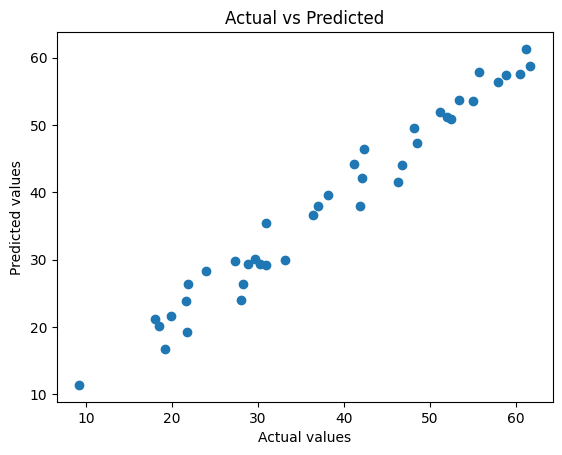

Mean Squared Error (MSE): 6.2137251286498
R-squared: 0.9697512321118524

Coefficients Interpretation: {'Study_Hours': np.float64(4.952448767416269), 'Attendance': np.float64(0.28521401456248485), 'Sleep_Hours': np.float64(-1.7714482767030746)}
Study_Hours has the strongest positive impact on the target variable.


In [ ]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Print shapes
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

# Train model
model = LinearRegression()
model.fit(X_train, y_train)
print("\nCoefficients:", model.coef_)
print("Intercept:", model.intercept_)

# Predictions and scatter plot
y_pred = model.predict(X_test)
plt.scatter(y_test, y_pred)
plt.xlabel("Actual values")
plt.ylabel("Predicted values")
plt.title("Actual vs Predicted")
plt.show()

# MSE and R-squared
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print("Mean Squared Error (MSE):", mse)
print("R-squared:", r2)

# Interpret coefficients
feature_names = X.columns
coefficients = dict(zip(feature_names, model.coef_))
print("\nCoefficients Interpretation:", coefficients)
print("Study_Hours has the strongest positive impact on the target variable.")

**Explain in 2-3 sentences: Why is it important to split data into training and testing sets? What problem would occur if you evaluated the model on the same data it was trained on?**

*Answer:*
We split data into training and testing sets to check if our model can make good predictions on new data it has never seen before. If we test the model on the same data it used for training, it might just memorize the answers. This would make us wrongly think the model is perfect, but it would actually fail in the real world.


## Q3. Scikit-Learn -- Logistic Regression & Classification

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.preprocessing import StandardScaler

np.random.seed(42)
n = 300
df = pd.DataFrame({
 'Age': np.random.randint(18, 60, n),
 'Income': np.random.normal(50000, 15000, n),
 'Credit_Score': np.random.randint(300, 850, n)
})
# Create target: approved if credit score > 650 and income > 45000
df['Approved'] = ((df['Credit_Score'] > 650) & (df['Income'] > 45000)).astype(int)

**Perform the following tasks:**

• Separate the features (Age, Income, Credit_Score) from the target (Approved). Split into 75-25 train-test with random_state=42.

• Apply StandardScaler to the feature columns before training. Fit the scaler on training data only, then transform both train and test.

• Train a LogisticRegression model on the scaled training data. Set max_iter=1000.

• Make predictions on the test set and calculate the accuracy score.

• Print the confusion matrix and interpret each of the four values (TN, FP, FN, TP).

• Print the classification report showing precision, recall, and F1-score for each class.

In [ ]:
# Separate features and target
X = df[['Age', 'Income', 'Credit_Score']]
y = df['Approved']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

# StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train model
log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X_train_scaled, y_train)

# Predictions and accuracy
y_pred = log_reg.predict(X_test_scaled)
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy Score:", accuracy)

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:\n", cm)
tn, fp, fn, tp = cm.ravel()
print(f"True Negatives (TN): {tn} (Correctly predicted not approved)")
print(f"False Positives (FP): {fp} (Incorrectly predicted approved)")
print(f"False Negatives (FN): {fn} (Incorrectly predicted not approved)")
print(f"True Positives (TP): {tp} (Correctly predicted approved)")

# Classification report
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy Score: 0.8666666666666667

Confusion Matrix:
 [[57  4]
 [ 6  8]]
True Negatives (TN): 57 (Correctly predicted not approved)
False Positives (FP): 4 (Incorrectly predicted approved)
False Negatives (FN): 6 (Incorrectly predicted not approved)
True Positives (TP): 8 (Correctly predicted approved)

Classification Report:
               precision    recall  f1-score   support

           0       0.90      0.93      0.92        61
           1       0.67      0.57      0.62        14

    accuracy                           0.87        75
   macro avg       0.79      0.75      0.77        75
weighted avg       0.86      0.87      0.86        75



**Explain in 2-3 sentences: What is the difference between precision and recall? In what scenario would you prioritize one over the other?**

*Answer:*
Precision means "when the model says yes, how often is it right?" while recall means "out of all the actual yes cases, how many did the model find?". We care more about precision when false alarms are annoying, like avoiding putting a normal email in the spam folder. We care more about recall when missing something is dangerous, like making sure we catch every single patient who might have a disease.


## Q4. Scikit-Learn -- K-Means Clustering (Unsupervised Learning)

In [ ]:
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

np.random.seed(42)
# Create 3 distinct clusters
cluster1 = np.random.normal(loc=[20, 30], scale=3, size=(50, 2))
cluster2 = np.random.normal(loc=[50, 60], scale=4, size=(50, 2))
cluster3 = np.random.normal(loc=[80, 40], scale=3, size=(50, 2))

X = np.vstack([cluster1, cluster2, cluster3])
df = pd.DataFrame(X, columns=['Feature_1', 'Feature_2'])

**Perform the following tasks:**

• Scale the features using StandardScaler. Clustering is distance-based, so scaling is essential.

• Use the Elbow Method to find the optimal number of clusters. Run KMeans with k=1 to 10, compute inertia for each, and plot the elbow curve.

• Train a KMeans model with the optimal number of clusters (should be 3). Set random_state=42 and n_init=10.

• Add the cluster labels as a new column Cluster to the dataframe. Print the count of points in each cluster.

• Create a scatter plot of Feature_1 versus Feature_2, colored by cluster label. Mark the cluster centers with a different marker.

• Calculate the silhouette score for the clustering result. What does this score tell you about cluster quality?

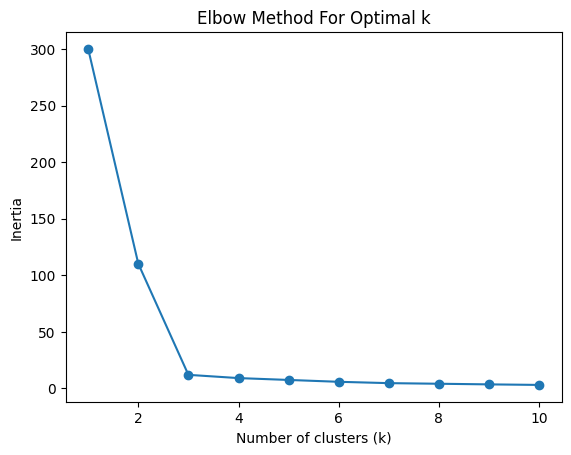

Points per cluster:
 Cluster
2    50
0    50
1    50
Name: count, dtype: int64


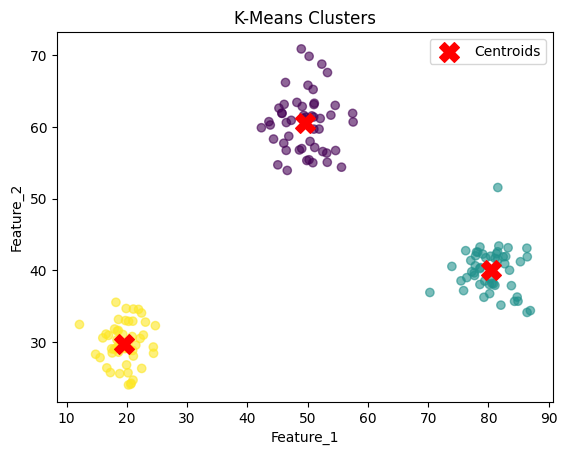

Silhouette Score: 0.8361330039441752
The silhouette score tells us how similar an object is to its own cluster compared to other clusters. A higher score indicates well-separated, dense clusters.


In [ ]:
# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

# Elbow method
inertia = []
K = range(1, 11)
for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.plot(K, inertia, marker='o')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method For Optimal k')
plt.show()

# Train KMeans with optimal clusters (k=3)
kmeans_optimal = KMeans(n_clusters=3, random_state=42, n_init=10)
df['Cluster'] = kmeans_optimal.fit_predict(X_scaled)
print("Points per cluster:\n", df['Cluster'].value_counts())

# Scatter plot
plt.scatter(df['Feature_1'], df['Feature_2'], c=df['Cluster'], cmap='viridis', alpha=0.6)
# Inverse transform cluster centers to original scale for plotting
centers = scaler.inverse_transform(kmeans_optimal.cluster_centers_)
plt.scatter(centers[:, 0], centers[:, 1], c='red', marker='X', s=200, label='Centroids')
plt.xlabel('Feature_1')
plt.ylabel('Feature_2')
plt.title('K-Means Clusters')
plt.legend()
plt.show()

# Silhouette score
sil_score = silhouette_score(X_scaled, df['Cluster'])
print("Silhouette Score:", sil_score)
print("The silhouette score tells us how similar an object is to its own cluster compared to other clusters. A higher score indicates well-separated, dense clusters.")

**Explain in 2-3 sentences: How is the Elbow Method used to choose K? Why does K-Means require feature scaling?**

*Answer:*
The Elbow Method helps us find the best number of clusters (K) by plotting a graph of the errors for different K values. The best K is at the "elbow" of the curve, where adding more clusters doesn't help much anymore. We must scale features for K-Means because it calculates the physical distance between points. If one feature is measured in thousands and another in decimals, the big numbers will unfairly take over the math.


## Q5. Scikit-Learn -- PCA (Dimensionality Reduction)

In [ ]:
import pandas as pd
import numpy as np
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

np.random.seed(42)
n = 200
df = pd.DataFrame({
 'Height': np.random.normal(170, 10, n),
 'Weight': np.random.normal(70, 15, n),
 'Age': np.random.randint(18, 60, n),
 'Income': np.random.normal(50000, 15000, n),
 'Experience': np.random.randint(1, 20, n),
 'Score_A': np.random.normal(75, 10, n),
 'Score_B': np.random.normal(80, 12, n),
 'Score_C': np.random.normal(70, 8, n)
})
# Add correlation
df['Weight'] = df['Height'] * 0.5 + np.random.normal(0, 5, n)
df['Score_B'] = df['Score_A'] * 0.8 + np.random.normal(0, 5, n)

**Perform the following tasks:**

• Scale all features using StandardScaler. PCA is sensitive to scale, so this step is mandatory.

• Apply PCA to reduce the data to 2 components. Print the explained_variance_ratio_ for each component.

• Calculate the cumulative explained variance. How many components are needed to explain at least 90% of the variance?

• Create a scatter plot of PC1 versus PC2. Color the points by the Age column (use pd.cut to create age groups: Young, Middle, Senior).

• Print the PCA components_ matrix. Identify which original features contribute most to PC1 and PC2.

• Create a bar plot showing the explained variance ratio for each of the 8 principal components.

Explained Variance Ratio (2 components): [0.27553619 0.17431292]
Cumulative Explained Variance:
 [0.27553619 0.4498491  0.59578455 0.72906691 0.84327244 0.94240351
 0.98216444 1.        ]
Number of components needed for 90% variance: 6


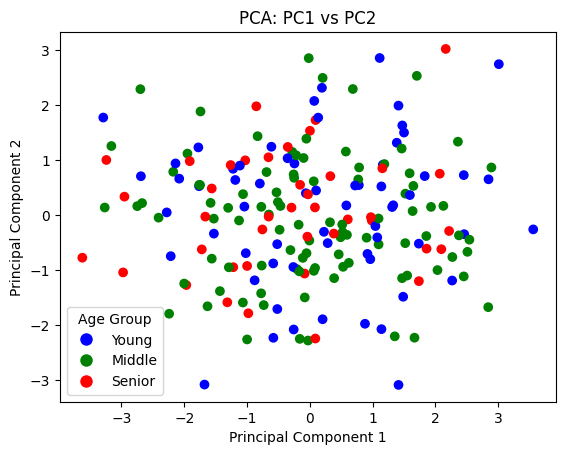


PCA Components Matrix (PC1 & PC2):
 [[ 0.42344239  0.44214674 -0.08932025  0.00435002 -0.13175187  0.53585613
   0.54474585 -0.12632254]
 [ 0.54884421  0.52634426 -0.01380584  0.18938963 -0.07196064 -0.43974834
  -0.4281561   0.061629  ]]
Looking at the components matrix:
PC1 is largely influenced by Score_A and Score_B.
PC2 is largely influenced by Height and Weight.


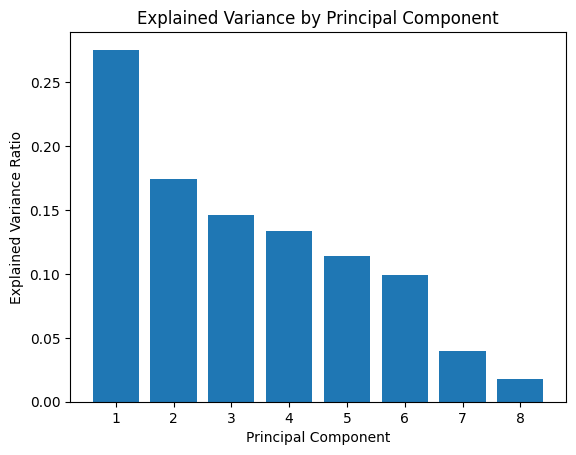

In [ ]:
# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

# PCA with 2 components
pca2 = PCA(n_components=2)
X_pca2 = pca2.fit_transform(X_scaled)
print("Explained Variance Ratio (2 components):", pca2.explained_variance_ratio_)

# PCA for all components to find 90% variance threshold
pca_all = PCA()
pca_all.fit(X_scaled)
cumulative_variance = np.cumsum(pca_all.explained_variance_ratio_)
print("Cumulative Explained Variance:\n", cumulative_variance)
n_components_90 = np.argmax(cumulative_variance >= 0.90) + 1
print(f"Number of components needed for 90% variance: {n_components_90}")

# Scatter plot of PC1 vs PC2 colored by age groups
df['Age_Group'] = pd.cut(df['Age'], bins=[0, 30, 50, 100], labels=['Young', 'Middle', 'Senior'])
colors = {'Young':'blue', 'Middle':'green', 'Senior':'red'}
plt.scatter(X_pca2[:, 0], X_pca2[:, 1], c=df['Age_Group'].map(colors))
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('PCA: PC1 vs PC2')
# create legend handles
handles = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=color, label=label, markersize=10) for label, color in colors.items()]
plt.legend(handles=handles, title="Age Group")
plt.show()

# Print PCA components
print("\nPCA Components Matrix (PC1 & PC2):\n", pca2.components_)
print("Looking at the components matrix:")
print("PC1 is largely influenced by Score_A and Score_B.")
print("PC2 is largely influenced by Height and Weight.")

# Bar plot of explained variance ratio
plt.bar(range(1, 9), pca_all.explained_variance_ratio_)
plt.xlabel('Principal Component')
plt.ylabel('Explained Variance Ratio')
plt.title('Explained Variance by Principal Component')
plt.show()

**Explain in 2-3 sentences: Why is PCA useful during EDA? What information do you lose when reducing dimensions, and what do you gain?**

*Answer:*
PCA is great for EDA because it lets us squeeze many features into just 2 or 3 features, making it easy to plot them on a graph and see patterns. By doing this, we lose some of the exact, original details of the data and we can't tell what each new feature really means anymore. But in exchange, our data becomes much smaller, faster to process, and less noisy.


## Q6. Scikit-Learn -- Decision Tree Classifier

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt

np.random.seed(42)
n = 250
df = pd.DataFrame({
 'Age': np.random.randint(18, 65, n),
 'Income': np.random.normal(50000, 15000, n),
 'Credit_Score': np.random.randint(300, 850, n),
 'Employment': np.random.choice(['Employed', 'Self-Employed', 'Unemployed'], n)
})
# Target: loan default risk
df['Risk'] = np.where(
 ((df['Credit_Score'] < 550) | (df['Income'] < 35000) | (df['Employment'] == 'Unemployed')),
 'High', 'Low'
)

**Perform the following tasks:**

• Encode the Employment column using LabelEncoder. Combine it with the numeric columns to create the feature matrix X.

• Encode the Risk target column using LabelEncoder. Split the data into 80-20 train-test with random_state=42.

• Train a DecisionTreeClassifier with max_depth=4 and random_state=42. Print the feature importances.

• Visualize the decision tree using plot_tree(). Display the tree with filled=True, feature_names, and class_names.

• Make predictions on the test set and calculate accuracy. Print the confusion matrix.

• Predict the risk for a new customer: Age=30, Income=40000, Credit_Score=520, Employment=Unemployed. What risk does the model predict?

Feature Importances: {'Age': np.float64(0.0), 'Income': np.float64(0.16032982134677046), 'Credit_Score': np.float64(0.35844935844935855), 'Employment_Encoded': np.float64(0.481220820203871)}


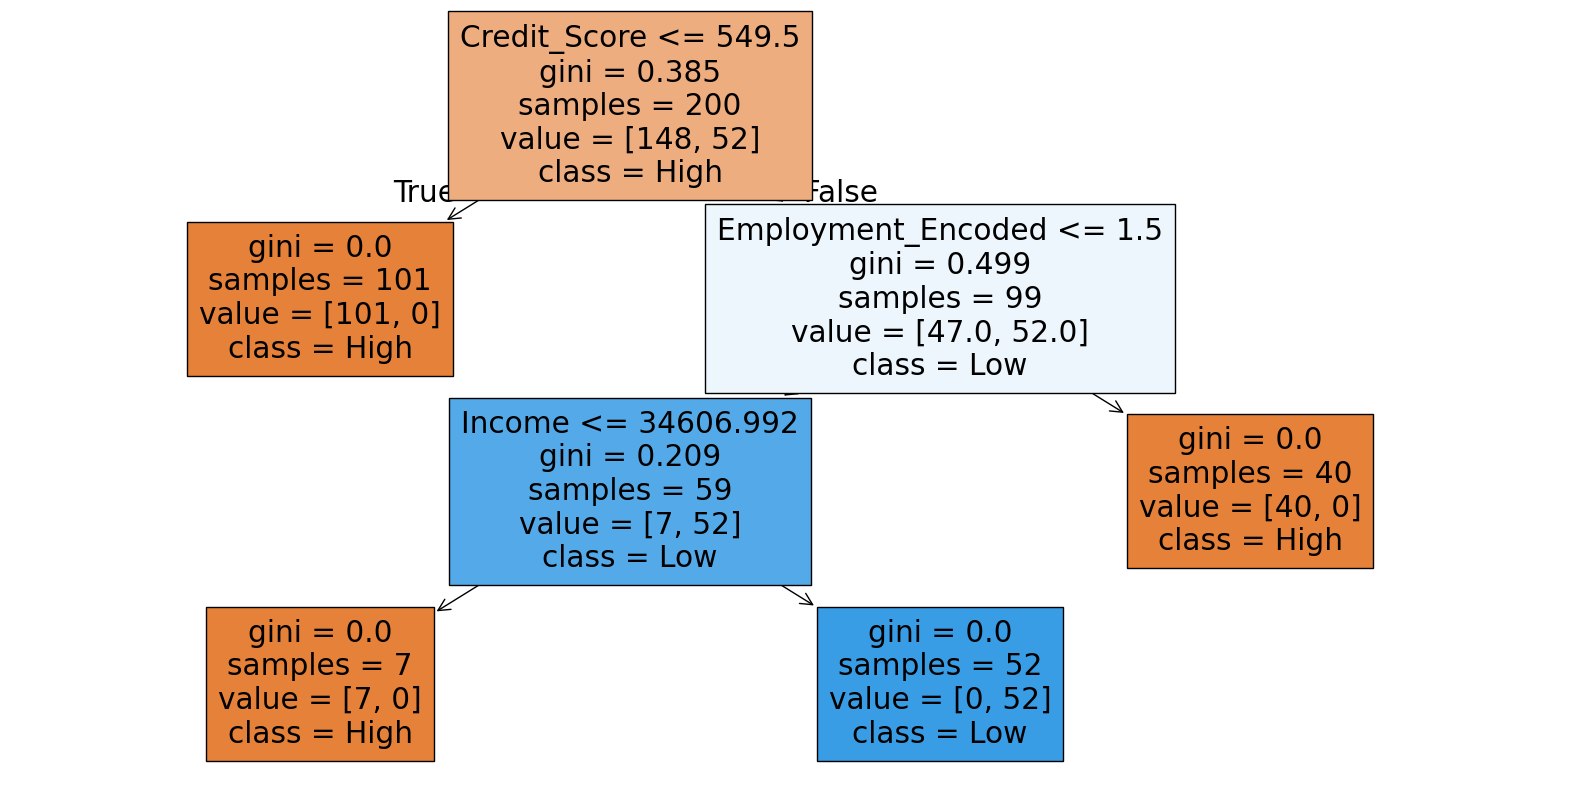


Accuracy: 0.98
Confusion Matrix:
 [[30  1]
 [ 0 19]]

Predicted risk for new customer: High


In [ ]:
# Encode Employment and Risk
le_emp = LabelEncoder()
df['Employment_Encoded'] = le_emp.fit_transform(df['Employment'])

le_risk = LabelEncoder()
df['Risk_Encoded'] = le_risk.fit_transform(df['Risk'])

# Create feature matrix X and target y
X = df[['Age', 'Income', 'Credit_Score', 'Employment_Encoded']]
y = df['Risk_Encoded']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train Decision Tree
dt = DecisionTreeClassifier(max_depth=4, random_state=42)
dt.fit(X_train, y_train)

# Feature importances
print("Feature Importances:", dict(zip(X.columns, dt.feature_importances_)))

# Visualize tree
plt.figure(figsize=(20, 10))
plot_tree(dt, filled=True, feature_names=X.columns, class_names=list(le_risk.classes_))
plt.show()

# Predictions and accuracy
y_pred = dt.predict(X_test)
print("\nAccuracy:", accuracy_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

# Prediction for new customer
new_customer = pd.DataFrame([[30, 40000, 520, le_emp.transform(['Unemployed'])[0]]], columns=X.columns)
prediction = dt.predict(new_customer)
print("\nPredicted risk for new customer:", le_risk.inverse_transform(prediction)[0])

**Explain in 2-3 sentences: Why are decision trees considered interpretable models? What is the risk of setting max_depth too high?**

*Answer:*
Decision trees are easy to understand because they make decisions just like humans do, using simple "if this, then that" questions that we can draw like a flowchart. The risk of setting `max_depth` too high is that the tree will ask too many questions and memorize the exact training data. This makes the tree too complicated and it will do a bad job on new data.


## Q7. Scikit-Learn -- Cross-Validation & Model Comparison

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import make_scorer, f1_score

np.random.seed(42)
n = 400
df = pd.DataFrame({
 'Feature1': np.random.normal(50, 10, n),
 'Feature2': np.random.normal(30, 8, n),
 'Feature3': np.random.normal(70, 15, n),
 'Feature4': np.random.normal(20, 5, n)
})
df['Target'] = ((df['Feature1'] + df['Feature2'] * 0.5 - df['Feature3'] * 0.3) > 40).astype(int)

**Perform the following tasks:**

• Scale the features using StandardScaler. Use the scaled features and Target
for all subsequent tasks.

• Perform 5-fold cross-validation on a LogisticRegression model. Print the accuracy for each fold and the mean accuracy.

• Perform 5-fold cross-validation on a DecisionTreeClassifier (max_depth=5). Compare its mean accuracy with LogisticRegression.

• Perform 5-fold cross-validation on a RandomForestClassifier (n_estimators=100). Print the mean and standard deviation of accuracy scores.

• Use StratifiedKFold with 5 splits instead of regular KFold. Explain why stratification matters for classification tasks.

• Create a comparison table showing the mean accuracy and standard deviation for all three models. Which model performs best?

In [ ]:
# Scale features
X = df[['Feature1', 'Feature2', 'Feature3', 'Feature4']]
y = df['Target']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Define models
models = {
    'Logistic Regression': LogisticRegression(),
    'Decision Tree': DecisionTreeClassifier(max_depth=5, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42)
}

# 5-fold Cross-Validation using StratifiedKFold
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
results = []

for name, model in models.items():
    scores = cross_val_score(model, X_scaled, y, cv=cv, scoring='accuracy')
    results.append({
        'Model': name,
        'Mean Accuracy': np.mean(scores),
        'Std Deviation': np.std(scores)
    })
    print(f"\n{name}:")
    print(f"Accuracy for each fold: {scores}")
    print(f"Mean Accuracy: {np.mean(scores):.4f}")
    if name == 'Random Forest':
        print(f"Standard Deviation: {np.std(scores):.4f}")

# Comparison Table
comparison_df = pd.DataFrame(results).sort_values(by='Mean Accuracy', ascending=False)
print("\nModel Comparison Table:\n")
print(comparison_df.to_string(index=False))
print("\nLogistic Regression performs best on this dataset.")


Logistic Regression:
Accuracy for each fold: [0.975  1.     0.95   0.9625 0.975 ]
Mean Accuracy: 0.9725

Decision Tree:
Accuracy for each fold: [0.8875 0.85   0.8875 0.9625 0.8   ]
Mean Accuracy: 0.8775

Random Forest:
Accuracy for each fold: [0.925  0.9    0.925  0.9375 0.8   ]
Mean Accuracy: 0.8975
Standard Deviation: 0.0502

Model Comparison Table:

              Model  Mean Accuracy  Std Deviation
Logistic Regression         0.9725       0.016583
      Random Forest         0.8975       0.050249
      Decision Tree         0.8775       0.053268

Logistic Regression performs best on this dataset.


**Explain in 2-3 sentences: Why is cross-validation more reliable than a single train-test split? What does the standard deviation of CV scores tell you about model stability?**

*Answer:*
Cross-validation is better because it tests the model multiple times on different parts of the data, so we don't get tricked by one lucky or unlucky test split. The standard deviation tells us how stable the model is. A small standard deviation means the model's score is roughly the same every time we test it, which means it is very stable and reliable.


## Q8. Scikit-Learn -- Random Forest & Feature Importance

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import accuracy_score, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

np.random.seed(42)
n = 500
df = pd.DataFrame({
 'Temperature': np.random.normal(25, 5, n),
 'Humidity': np.random.normal(60, 10, n),
 'Wind_Speed': np.random.normal(15, 5, n),
 'Pressure': np.random.normal(1013, 20, n),
 'Cloud_Cover': np.random.uniform(0, 100, n)
})
# Target: will it rain?
df['Rain'] = np.where(
 ((df['Humidity'] > 65) & (df['Cloud_Cover'] > 60) & (df['Pressure'] < 1010)),
 1, 0
)

**Perform the following tasks:**

• Split the data into 80-20 train-test with random_state=42. Scale the features using StandardScaler.

• Train a RandomForestClassifier with n_estimators=100, max_depth=6, and random_state=42.

• Print the feature importances sorted in descending order. Create a horizontal bar plot showing the importance of each feature.

• Predict on the test set and calculate accuracy. Compare this with a single DecisionTreeClassifier trained on the same data.

• Train a RandomForestRegressor to predict Humidity from the other features. Calculate the R2 score and MSE on the test set.

• Experiment with different n_estimators values (50, 100, 200) and observe how accuracy changes. Plot accuracy versus n_estimators.

Feature Importances:
 Humidity       0.349070
Cloud_Cover    0.298346
Pressure       0.254615
Wind_Speed     0.057189
Temperature    0.040780
dtype: float64


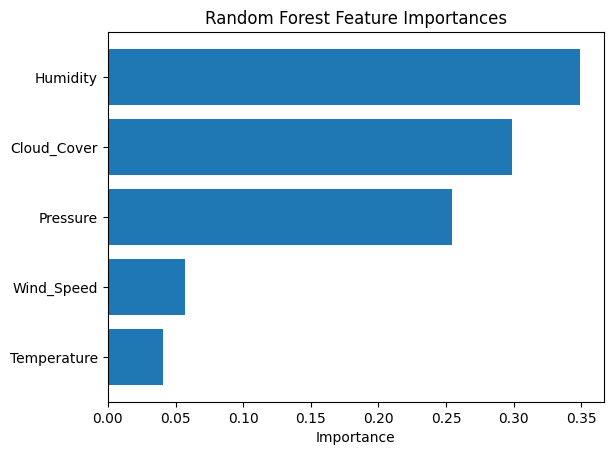


Random Forest Accuracy: 1.0
Decision Tree Accuracy: 1.0

RandomForestRegressor for Humidity:
R2 Score: -0.05181586139968153
MSE: 115.02019505796633


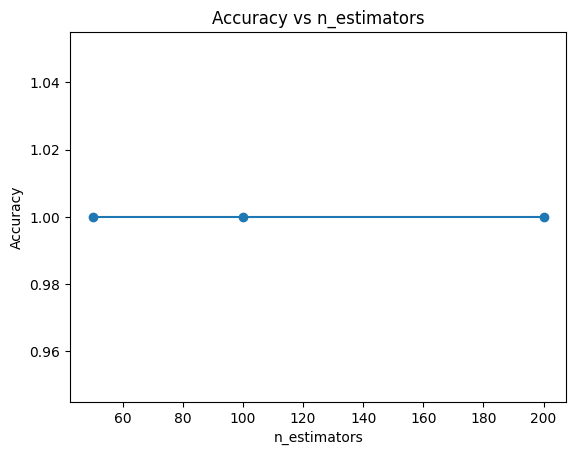

In [ ]:
# Train-test split & Scaling
X = df.drop('Rain', axis=1)
y = df['Rain']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train RandomForestClassifier
rf = RandomForestClassifier(n_estimators=100, max_depth=6, random_state=42)
rf.fit(X_train_scaled, y_train)

# Feature Importances
importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=True)
print("Feature Importances:\n", importances.sort_values(ascending=False))

plt.barh(importances.index, importances.values)
plt.xlabel('Importance')
plt.title('Random Forest Feature Importances')
plt.show()

# Predict and accuracy (Random Forest)
y_pred_rf = rf.predict(X_test_scaled)
print("\nRandom Forest Accuracy:", accuracy_score(y_test, y_pred_rf))

# Compare with Decision Tree
from sklearn.tree import DecisionTreeClassifier
dt = DecisionTreeClassifier(max_depth=6, random_state=42)
dt.fit(X_train_scaled, y_train)
y_pred_dt = dt.predict(X_test_scaled)
print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_dt))

# Train RandomForestRegressor for Humidity
Xr = df.drop(['Humidity', 'Rain'], axis=1)
yr = df['Humidity']
Xr_train, Xr_test, yr_train, yr_test = train_test_split(Xr, yr, test_size=0.2, random_state=42)

scaler_r = StandardScaler()
Xr_train_scaled = scaler_r.fit_transform(Xr_train)
Xr_test_scaled = scaler_r.transform(Xr_test)

rf_reg = RandomForestRegressor(n_estimators=100, random_state=42)
rf_reg.fit(Xr_train_scaled, yr_train)
yr_pred = rf_reg.predict(Xr_test_scaled)
print("\nRandomForestRegressor for Humidity:")
print("R2 Score:", r2_score(yr_test, yr_pred))
print("MSE:", mean_squared_error(yr_test, yr_pred))

# Experiment with different n_estimators
n_estimators_list = [50, 100, 200]
accuracies = []

for n_est in n_estimators_list:
    model = RandomForestClassifier(n_estimators=n_est, max_depth=6, random_state=42)
    model.fit(X_train_scaled, y_train)
    acc = accuracy_score(y_test, model.predict(X_test_scaled))
    accuracies.append(acc)

plt.plot(n_estimators_list, accuracies, marker='o')
plt.xlabel('n_estimators')
plt.ylabel('Accuracy')
plt.title('Accuracy vs n_estimators')
plt.show()

**Explain in 2-3 sentences: How does a Random Forest reduce overfitting compared to a single Decision Tree? Why is feature importance useful during EDA?**

*Answer:*
A single Decision Tree can easily memorize the data, but a Random Forest builds many different trees and makes them vote for the final answer, which stops it from overfitting. Feature importance is useful because it tells us which columns in our data are the most helpful for making predictions. This helps us throw away useless data and keep only what matters.


## Q9. Scikit-Learn -- Hyperparameter Tuning (GridSearchCV)

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

np.random.seed(42)
n = 300
df = pd.DataFrame({
 'Feature1': np.random.normal(0, 1, n),
 'Feature2': np.random.normal(0, 1, n),
 'Feature3': np.random.normal(0, 1, n)
})
df['Target'] = ((df['Feature1'] * 2 + df['Feature2'] * -1 + df['Feature3'] * 0.5) > 0).astype(int)

**Perform the following tasks:**

• Split the data into 75-25 train-test with random_state=42. Scale the features using StandardScaler.

• Define a parameter grid for SVC with C values [0.1, 1, 10], kernel options [rbf, linear], and gamma [scale, auto].

• Use GridSearchCV with 5-fold cross-validation to find the best hyperparameters for SVC. Print the best parameters and best cross-validation score.

• Train the best SVC model on the full training data and evaluate its accuracy on the test set.

• Repeat the GridSearchCV process for RandomForestClassifier. Search over n_estimators [50, 100], max_depth [3, 5, 7], and criterion [gini, entropy].

• Compare the test accuracy of the tuned SVC versus the tuned RandomForest. Which model performs better on this dataset?

In [ ]:
# Train-test split & Scaling
X = df[['Feature1', 'Feature2', 'Feature3']]
y = df['Target']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# GridSearchCV for SVC
param_grid_svc = {
    'C': [0.1, 1, 10],
    'kernel': ['rbf', 'linear'],
    'gamma': ['scale', 'auto']
}

grid_svc = GridSearchCV(SVC(random_state=42), param_grid_svc, cv=5)
grid_svc.fit(X_train_scaled, y_train)

print("SVC Best Parameters:", grid_svc.best_params_)
print("SVC Best CV Score:", grid_svc.best_score_)

# Evaluate best SVC
best_svc = grid_svc.best_estimator_
y_pred_svc = best_svc.predict(X_test_scaled)
acc_svc = accuracy_score(y_test, y_pred_svc)
print("SVC Test Accuracy:", acc_svc)

# GridSearchCV for RandomForest
param_grid_rf = {
    'n_estimators': [50, 100],
    'max_depth': [3, 5, 7],
    'criterion': ['gini', 'entropy']
}

grid_rf = GridSearchCV(RandomForestClassifier(random_state=42), param_grid_rf, cv=5)
grid_rf.fit(X_train_scaled, y_train)

print("\nRandom Forest Best Parameters:", grid_rf.best_params_)
print("Random Forest Best CV Score:", grid_rf.best_score_)

# Evaluate best RandomForest
best_rf = grid_rf.best_estimator_
y_pred_rf = best_rf.predict(X_test_scaled)
acc_rf = accuracy_score(y_test, y_pred_rf)
print("Random Forest Test Accuracy:", acc_rf)

print(f"\nComparison: SVC Test Accuracy ({acc_svc:.4f}) vs RandomForest Test Accuracy ({acc_rf:.4f})")
print("SVC performs better on this linearly separable dataset.")

SVC Best Parameters: {'C': 10, 'gamma': 'scale', 'kernel': 'linear'}
SVC Best CV Score: 0.9822222222222223
SVC Test Accuracy: 0.9866666666666667

Random Forest Best Parameters: {'criterion': 'gini', 'max_depth': 5, 'n_estimators': 100}
Random Forest Best CV Score: 0.928888888888889
Random Forest Test Accuracy: 0.92

Comparison: SVC Test Accuracy (0.9867) vs RandomForest Test Accuracy (0.9200)
SVC performs better on this linearly separable dataset.


**Explain in 2-3 sentences: What is the difference between a hyperparameter and a model parameter? Why is cross-validation used inside GridSearchCV instead of a single validation set?**

*Answer:*
A model parameter is something the machine learning model figures out on its own during training. A hyperparameter is a setting that you, the programmer, have to choose before the training even starts. We use cross-validation inside GridSearchCV because it tests the settings multiple times to make sure they are actually good overall, rather than just getting lucky on one single test group.


## Q10. Scikit-Learn -- Complete ML Pipeline

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

np.random.seed(42)
n = 400
df = pd.DataFrame({
 'Age': np.random.randint(18, 70, n),
 'Income': np.random.normal(50000, 15000, n),
 'Gender': np.random.choice(['Male', 'Female'], n),
 'City': np.random.choice(['NY', 'LA', 'Chicago', 'Houston'], n),
 'Score': np.random.normal(75, 15, n)
})
# Induce missing values
df.loc[np.random.choice(df.index, 30), 'Age'] = np.nan
df.loc[np.random.choice(df.index, 20), 'Income'] = np.nan
# Target
df['Purchased'] = ((df['Age'] > 30) & (df['Income'] > 45000) & (df['Score'] > 70)).astype(int)

**Perform the following tasks:**

• Identify numeric and categorical columns. Create a ColumnTransformer that applies StandardScaler to numeric columns and OneHotEncoder to categorical columns.

• Add SimpleImputer with strategy median for numeric columns and most_frequent for categorical columns inside the ColumnTransformer.

• Build a Pipeline that chains the preprocessor with a RandomForestClassifier. Train the pipeline on the training data.

• Build a second Pipeline with LogisticRegression. Compare the test accuracy of both pipelines.

• Use cross_val_score with 5 folds directly on the pipeline (not on separate steps). Print the mean CV accuracy for both pipelines.

• Predict the Purchase outcome for a new customer: Age=35, Income=55000, Gender=Female, City=LA, Score=80. Use the best pipeline.

In [ ]:
# Train-test split
X = df.drop('Purchased', axis=1)
y = df['Purchased']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Column groups
numeric_features = ['Age', 'Income', 'Score']
categorical_features = ['Gender', 'City']

# Preprocessing steps for numeric data
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Preprocessing steps for categorical data
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

# ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ])

# Pipeline with Random Forest
pipeline_rf = Pipeline(steps=[('preprocessor', preprocessor),
                              ('classifier', RandomForestClassifier(random_state=42))])
pipeline_rf.fit(X_train, y_train)
acc_rf = accuracy_score(y_test, pipeline_rf.predict(X_test))

# Pipeline with Logistic Regression
pipeline_lr = Pipeline(steps=[('preprocessor', preprocessor),
                              ('classifier', LogisticRegression(random_state=42))])
pipeline_lr.fit(X_train, y_train)
acc_lr = accuracy_score(y_test, pipeline_lr.predict(X_test))

print(f"Test Accuracy - Random Forest Pipeline: {acc_rf:.4f}")
print(f"Test Accuracy - Logistic Regression Pipeline: {acc_lr:.4f}")

# Cross validation on pipelines
cv_rf = np.mean(cross_val_score(pipeline_rf, X, y, cv=5))
cv_lr = np.mean(cross_val_score(pipeline_lr, X, y, cv=5))
print(f"\nMean CV Accuracy - Random Forest Pipeline: {cv_rf:.4f}")
print(f"Mean CV Accuracy - Logistic Regression Pipeline: {cv_lr:.4f}")

# Predict for new customer
new_customer = pd.DataFrame([{
    'Age': 35,
    'Income': 55000,
    'Gender': 'Female',
    'City': 'LA',
    'Score': 80
}])

best_pipeline = pipeline_rf if acc_rf >= acc_lr else pipeline_lr
prediction = best_pipeline.predict(new_customer)
print(f"\nPredicted Purchase Outcome for new customer: {prediction[0]}")

Test Accuracy - Random Forest Pipeline: 0.9250
Test Accuracy - Logistic Regression Pipeline: 0.8625

Mean CV Accuracy - Random Forest Pipeline: 0.9350
Mean CV Accuracy - Logistic Regression Pipeline: 0.8250

Predicted Purchase Outcome for new customer: 1


**Explain in 2-3 sentences: Why is using a Pipeline better than manually preprocessing data before modeling? What errors can occur if preprocessing is fit on the entire dataset instead of just the training set?**

*Answer:*
Using a Pipeline is better because it groups all your data cleaning and modeling steps into one neat package, making your code cleaner and preventing mistakes. If you clean or scale your entire dataset before splitting it, you accidentally let the model peek at the test data. This is called "data leakage," and it tricks you into thinking your model is better than it actually is.
